In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 │ ⚙️ CONFIG + LOAD DATASET
# ─────────────────────────────────────────────────────────────────────────────

import os
import re
import json
import random

from pathlib import Path
from datetime import datetime

from dotenv import load_dotenv
from openai import OpenAI
from transformers import AutoTokenizer
from vllm import LLM, SamplingParams

# =============================================================================
# Load environment variables
# =============================================================================

load_dotenv()

# =============================================================================
# Inference Model (API)
# =============================================================================

MODEL_PROVIDER = os.getenv("MODEL_PROVIDER", "openai")

MODEL_NAME = os.getenv("MODEL_NAME")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

# =============================================================================
# Benchmark Config
# =============================================================================

DATASET_PATH = "data/test-final_v3.jsonl"

RANDOM_SEED = 42

MAX_NEW_TOKENS = int(os.getenv("MAX_NEW_TOKENS", 128))
TEMPERATURE = float(os.getenv("TEMPERATURE", 0.0))

BATCH_SIZE = 8

# Chỉ còn dùng nếu benchmark local trong tương lai
MAX_MODEL_LEN = 2048
GPU_MEM_UTIL = 0.80

# =============================================================================
# Judge model (LOCAL)
# =============================================================================

JUDGE_MODEL_NAME = "/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/Qwen3-8B"

JUDGE_MAX_MODEL_LEN = 4096
JUDGE_MAX_NEW_TOKENS = 768
JUDGE_GPU_MEM_UTIL = 0.80
JUDGE_BATCH_SIZE = 16

# =============================================================================
# Run name
# =============================================================================

RUN_NAME = "gpt41_mini_domain_test"

# Chỉ sinh OUTPUT_DIR một lần duy nhất (không gắn timestamp).
# Các lần chạy sau sẽ ghi đè lên nội dung cũ trong cùng thư mục này.

OUTPUT_DIR = Path(f"./benchmark_outputs/{RUN_NAME}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("MODEL_PROVIDER:", MODEL_PROVIDER)
print("MODEL_NAME:", MODEL_NAME)

# =============================================================================
# Dataset utilities
# =============================================================================

def extract_context_question(user_content):
    user_content = str(user_content).strip()

    context_match = re.search(
        r"(?:Context|Ngữ cảnh)\s*:\s*(.*?)\s*(?:Question|Câu hỏi)\s*:",
        user_content,
        flags=re.DOTALL | re.IGNORECASE
    )

    question_match = re.search(
        r"(?:Question|Câu hỏi)\s*:\s*(.*)",
        user_content,
        flags=re.DOTALL | re.IGNORECASE
    )

    context = context_match.group(1).strip() if context_match else ""
    question = question_match.group(1).strip() if question_match else ""

    return context, question


REFUSAL_GOLD = "Không có thông tin trong ngữ cảnh được cung cấp."


def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


REFUSAL_GOLD_NORM = normalize_text(REFUSAL_GOLD)


def is_gold_unanswerable(ans):
    return normalize_text(ans) == REFUSAL_GOLD_NORM


# =============================================================================
# Load dataset
# =============================================================================

samples = []

with open(DATASET_PATH, "r", encoding="utf-8") as f:

    for idx, line in enumerate(f):

        item = json.loads(line)
        messages = item["messages"]

        system_msg = messages[0]["content"].strip()
        user_msg = messages[1]["content"].strip()
        gold_answer = messages[2]["content"].strip()

        context, question = extract_context_question(user_msg)

        samples.append(
            {
                "id": f"sample_{idx}",
                "context": context,
                "question": question,
                "gold_answers": [gold_answer],
                "gold_answer": gold_answer,
                "is_unanswerable": is_gold_unanswerable(gold_answer),
                "messages": [
                    {
                        "role": "system",
                        "content": system_msg,
                    },
                    {
                        "role": "user",
                        "content": user_msg,
                    },
                ],
            }
        )

print("Loaded samples:", len(samples))
print("Example question:", samples[0]["question"])
print("Example gold:", samples[0]["gold_answer"])

/opt/miniconda3/envs/qwen3_bm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 07-24 07:15:23 [__init__.py:216] Automatically detected platform cuda.
OUTPUT_DIR: /home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/gpt41_mini_domain_test
MODEL_PROVIDER: openai
MODEL_NAME: gpt-4o-mini
Loaded samples: 430
Example question: Tài khoản đăng nhập EOS là tài khoản nào?
Example gold: Tài khoản đăng nhập EOS/PEA chính là tài khoản Wi-Fi FU-Student của sinh viên.


In [2]:
import subprocess

print(subprocess.getoutput("nvidia-smi"))

llm = None
tokenizer = None
client = None
sampling_params = None

if MODEL_PROVIDER.lower() == "local":

    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_NAME,
        trust_remote_code=True
    )

    llm = LLM(
        model=MODEL_NAME,
        trust_remote_code=True,
        dtype="half",
        quantization=None,
        max_model_len=MAX_MODEL_LEN,
        gpu_memory_utilization=GPU_MEM_UTIL,
        enforce_eager=True,
        max_num_seqs=BATCH_SIZE,
        limit_mm_per_prompt={"image": 0},
    )

    sampling_params = SamplingParams(
        temperature=TEMPERATURE,
        max_tokens=MAX_NEW_TOKENS,
    )

    print(f"Loaded LOCAL model: {MODEL_NAME}")

elif MODEL_PROVIDER.lower() == "openai":

    client = OpenAI(api_key=OPENAI_API_KEY)

    print(f"Using OpenAI API: {MODEL_NAME}")

else:
    raise ValueError(f"Unsupported MODEL_PROVIDER: {MODEL_PROVIDER}")

Fri Jul 24 07:15:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:01:00.0  On |                  Off |
|  0%   53C    P8              9W /  450W |     447MiB /  24564MiB |     29%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 │ 🔮 INFERENCE
# ─────────────────────────────────────────────────────────────────────────────

import time

predictions = []

start_time = time.time()

# ============================================================================
# LOCAL (vLLM)
# ============================================================================

if MODEL_PROVIDER.lower() == "local":

    prompts = []

    for s in samples:
        prompt = tokenizer.apply_chat_template(
            s["messages"],
            tokenize=False,
            add_generation_prompt=True
        )
        prompts.append(prompt)

    print("Total prompts:", len(prompts))
    print("Prompt preview:")
    print(prompts[0][:1000])

    outputs = llm.generate(
        prompts,
        sampling_params,
        use_tqdm=True
    )

    predictions = [
        output.outputs[0].text.strip()
        for output in outputs
    ]

# ============================================================================
# OPENAI
# ============================================================================

elif MODEL_PROVIDER.lower() == "openai":

    from tqdm import tqdm

    for s in tqdm(samples):

        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=s["messages"],
            temperature=TEMPERATURE,
            max_tokens=MAX_NEW_TOKENS,
        )

        predictions.append(
            response.choices[0].message.content.strip()
        )

else:
    raise ValueError(f"Unsupported MODEL_PROVIDER: {MODEL_PROVIDER}")

# ============================================================================
# Save predictions
# ============================================================================

total_time = time.time() - start_time

for s, pred in zip(samples, predictions):
    s["prediction"] = pred

print("\n✅ Inference completed")
print("Total time:", round(total_time, 2), "seconds")
print("Avg latency:", round(total_time / len(samples), 4), "sec/sample")
print("Throughput:", round(len(samples) / total_time, 2), "samples/sec")

print("\nPrediction example:")
print(predictions[0])

100%|██████████| 430/430 [07:26<00:00,  1.04s/it]


✅ Inference completed
Total time: 446.03 seconds
Avg latency: 1.0373 sec/sample
Throughput: 0.96 samples/sec

Prediction example:
Tài khoản đăng nhập EOS là tài khoản Wi-Fi FU-Student của sinh viên.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 │ 🧹 GIẢI PHÓNG VRAM CỦA MODEL INFERENCE TRƯỚC KHI LOAD JUDGE MODEL
#            (bắt buộc để tránh OOM khi chạy 2 model vLLM tuần tự trên cùng 1 GPU)
# ─────────────────────────────────────────────────────────────────────────────
import gc
import torch

def unload_vllm(llm_instance):
    """Giải phóng toàn bộ VRAM đang bị vLLM giữ (weights + KV cache)."""
    try:
        from vllm.distributed.parallel_state import (
            destroy_model_parallel,
            destroy_distributed_environment,
        )
        destroy_model_parallel()
        destroy_distributed_environment()
    except Exception as e:
        print("Cảnh báo khi destroy vLLM parallel state:", e)

    try:
        del llm_instance.llm_engine.model_executor
    except Exception:
        pass

    del llm_instance
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

unload_vllm(llm)
del llm
gc.collect()
torch.cuda.empty_cache()

print("Đã giải phóng VRAM của model inference.")
print(subprocess.getoutput("nvidia-smi"))

Đã giải phóng VRAM của model inference.
Fri Jul 24 07:22:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:01:00.0  On |                  Off |
|  0%   54C    P8             16W /  450W |     839MiB /  24564MiB |     24%      Default |
|                                         |                        |                  N/A |
+-------

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 │ ⚖️ LOAD QWEN3-8B LÀM LLM JUDGE (local, thay cho gọi API)
# ─────────────────────────────────────────────────────────────────────────────
import inspect
from vllm import LLM as JudgeLLM, SamplingParams as JudgeSamplingParams
from pydantic import BaseModel, Field

class JudgeResult(BaseModel):
    # ĐƯA REASONING LÊN ĐẦU ĐỂ ÉP MÔ HÌNH SUY LUẬN TRƯỚC KHI CHẤM ĐIỂM (Chain-of-Thought)
    # Giữ lại field này vì nó ảnh hưởng trực tiếp tới chất lượng suy luận
    # và độ chính xác của các điểm số bên dưới.
    reasoning: str = Field(description="Phân tích và giải thích ngắn gọn (dưới 30 từ) lý do chấm điểm trước khi đưa ra kết quả.")

    is_refusal: bool = Field(description="True nếu mô hình từ chối trả lời vì thiếu thông tin trong ngữ cảnh.")
    is_hallucination: bool = Field(description="True nếu mô hình tự bịa ra thông tin không hề có trong ngữ cảnh (chỉ tính thông tin sai lệch, không tính diễn đạt khác).")
    faithfulness: float = Field(description="Độ trung thành với ngữ cảnh. Chỉ dùng các mức: 0.0 (bịa đặt hoàn toàn), 0.5 (có dựa vào ngữ cảnh nhưng suy diễn thêm), 1.0 (hoàn toàn dựa vào ngữ cảnh hoặc từ chối đúng vì ngữ cảnh không có).")

JUDGE_SCHEMA = JudgeResult.model_json_schema()

judge_tokenizer = AutoTokenizer.from_pretrained(
    JUDGE_MODEL_NAME,
    trust_remote_code=True
)

if not hasattr(judge_tokenizer, "all_special_tokens_extended"):
    judge_tokenizer.all_special_tokens_extended = judge_tokenizer.all_special_tokens

judge_llm = JudgeLLM(
    model=JUDGE_MODEL_NAME,
    trust_remote_code=True,
    dtype="half",
    max_model_len=JUDGE_MAX_MODEL_LEN,
    gpu_memory_utilization=JUDGE_GPU_MEM_UTIL,
    enforce_eager=True,
    max_num_seqs=JUDGE_BATCH_SIZE,
)

# Guided decoding: API đổi qua nhiều bản vLLM, nên tự dò thay vì import cứng.
def build_judge_sampling_params():
    try:
        from vllm.sampling_params import GuidedDecodingParams
        return JudgeSamplingParams(
            temperature=0.0,
            max_tokens=JUDGE_MAX_NEW_TOKENS,
            guided_decoding=GuidedDecodingParams(json=JUDGE_SCHEMA)
        )
    except ImportError:
        pass

    try:
        from vllm.model_executor.guided_decoding.guided_fields import GuidedDecodingParams
        return JudgeSamplingParams(
            temperature=0.0,
            max_tokens=JUDGE_MAX_NEW_TOKENS,
            guided_decoding=GuidedDecodingParams(json=JUDGE_SCHEMA)
        )
    except ImportError:
        pass

    if "guided_json" in inspect.signature(JudgeSamplingParams.__init__).parameters:
        return JudgeSamplingParams(
            temperature=0.0,
            max_tokens=JUDGE_MAX_NEW_TOKENS,
            guided_json=JUDGE_SCHEMA
        )

    print("⚠️ Phiên bản vLLM hiện tại không hỗ trợ guided decoding — "
          "sẽ ép JSON qua prompt, có fallback parser ở bước evaluation.")
    return JudgeSamplingParams(
        temperature=0.0,
        max_tokens=JUDGE_MAX_NEW_TOKENS
    )

judge_sampling_params = build_judge_sampling_params()

print("✅ Judge model loaded successfully.")

INFO 07-24 07:22:50 [utils.py:328] non-default args: {'trust_remote_code': True, 'dtype': 'half', 'max_model_len': 4096, 'gpu_memory_utilization': 0.8, 'max_num_seqs': 16, 'disable_log_stats': True, 'enforce_eager': True, 'model': '/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/Qwen3-8B'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


INFO 07-24 07:22:55 [__init__.py:742] Resolved architecture: Qwen3ForCausalLM


`torch_dtype` is deprecated! Use `dtype` instead!


WARNING 07-24 07:22:55 [__init__.py:2767] Casting torch.bfloat16 to torch.float16.
INFO 07-24 07:22:55 [__init__.py:1815] Using max model len 4096


...

INFO 07-24 07:22:56 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 07-24 07:22:56 [__init__.py:3400] Cudagraph is disabled under eager mode
WARNING 07-24 07:22:56 [__init__.py:2974] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
INFO 07-24 07:22:58 [__init__.py:216] Automatically detected platform cuda.
(EngineCore_DP0 pid=1344108) INFO 07-24 07:22:59 [core.py:654] Waiting for init message from front-end.
(EngineCore_DP0 pid=1344108) INFO 07-24 07:22:59 [core.py:76] Initializing a V1 LLM engine (v0.10.2) with config: model='/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/Qwen3-8B', speculative_config=None, tokenizer='/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/Qwen3-8B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_re

[W724 07:23:01.775968233 ProcessGroupNCCL.cpp:981] Warning: TORCH_NCCL_AVOID_RECORD_STREAMS is the default now, this environment variable is thus deprecated. (function operator())


[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
(EngineCore_DP0 pid=1344108) INFO 07-24 07:23:01 [parallel_state.py:1165] rank 0 in world size 1 is assigned as DP rank 0, PP rank 0, TP rank 0, EP rank 0
(EngineCore_DP0 pid=1344108) WARNING 07-24 07:23:01 [topk_topp_sampler.py:69] FlashInfer is not available. Falling back to the PyTorch-native implementation of top-p & top-k sampling. For the best performance, please install FlashInfer.
(EngineCore_DP0 pid=1344108) INFO 07-24 07:23:01 [gpu_model_ru

Loading safetensors checkpoint shards:   0% Completed | 0/5 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  20% Completed | 1/5 [00:00<00:01,  3.07it/s]
Loading safetensors checkpoint shards:  40% Completed | 2/5 [00:01<00:02,  1.46it/s]
Loading safetensors checkpoint shards:  60% Completed | 3/5 [00:02<00:01,  1.08it/s]
Loading safetensors checkpoint shards:  80% Completed | 4/5 [00:03<00:01,  1.03s/it]
Loading safetensors checkpoint shards: 100% Completed | 5/5 [00:04<00:00,  1.08s/it]
Loading safetensors checkpoint shards: 100% Completed | 5/5 [00:04<00:00,  1.03it/s]
(EngineCore_DP0 pid=1344108) 


(EngineCore_DP0 pid=1344108) INFO 07-24 07:23:06 [default_loader.py:268] Loading weights took 4.89 seconds
(EngineCore_DP0 pid=1344108) INFO 07-24 07:23:07 [gpu_model_runner.py:2392] Model loading took 15.2683 GiB and 4.955694 seconds
(EngineCore_DP0 pid=1344108) INFO 07-24 07:23:08 [gpu_worker.py:298] Available KV cache memory: 2.70 GiB
(EngineCore_DP0 pid=1344108) INFO 07-24 07:23:08 [kv_cache_utils.py:864] GPU KV cache size: 19,664 tokens
(EngineCore_DP0 pid=1344108) INFO 07-24 07:23:08 [kv_cache_utils.py:868] Maximum concurrency for 4,096 tokens per request: 4.80x
(EngineCore_DP0 pid=1344108) INFO 07-24 07:23:08 [gpu_worker.py:391] Free memory on device (22.28/23.51 GiB) on startup. Desired GPU memory utilization is (0.8, 18.81 GiB). Actual usage is 15.27 GiB for weight, 0.82 GiB for peak activation, 0.02 GiB for non-torch memory, and 0.0 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=2743752704` to fit into requested memory, or `--kv-cache-

In [6]:
import transformers
import vllm

print(transformers.__version__)
print(vllm.__version__)

4.56.1
0.10.2


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 │ EVALUATION METRICS — LLM-AS-A-JUDGE (refusal / hallucination / faithfulness)
#            + RULE-BASED METRICS (EM / F1 / ROUGE-L / Containment / Context Recall / Token-Faithfulness)
# ─────────────────────────────────────────────────────────────────────────────

import os
import re
import json
import unicodedata
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm

REFUSAL_GOLD = "Không có thông tin trong ngữ cảnh được cung cấp."

def build_judge_prompt(context: str, question: str, gold: str, pred: str) -> str:
    return f"""Bạn là một giám khảo AI chuyên nghiệp, khách quan.
Nhiệm vụ: Đánh giá câu trả lời của [Mô hình] dựa trên [Ngữ cảnh] do hệ thống RAG cung cấp và [Đáp án chuẩn] của con người.

[Dữ liệu]
- Ngữ cảnh: {context}
- Câu hỏi: {question}
- Đáp án chuẩn: {gold}
- Mô hình trả lời: {pred}

[Tiêu chí chấm điểm khắt khe]
1. Về Từ chối (Refusal): Nếu mô hình nói rằng không có đủ thông tin để trả lời, set is_refusal = True.
2. Từ chối đúng (Expected Refusal): Nếu [Đáp án chuẩn] thể hiện việc không thể trả lời, và [Mô hình] cũng từ chối -> Đánh giá faithfulness = 1.0.
3. Ảo tưởng (Hallucination): Nếu [Mô hình] đưa ra chi tiết cụ thể (tên, số, quy định) KHÔNG xuất hiện trong [Ngữ cảnh], set is_hallucination = True và faithfulness = 0.0.

Hãy suy luận kỹ (reasoning) trước khi chốt điểm số. Chỉ trả về JSON đúng theo schema, không thêm văn bản khác.
"""

# ── Build tất cả prompt cho judge và gọi vLLM theo batch (thay cho ThreadPoolExecutor + API) ──
judge_chat_prompts = []
for s in samples:
    user_prompt = build_judge_prompt(
        s.get("context", ""), s["question"], s["gold_answer"], s["prediction"]
    )
    judge_chat_prompts.append(
        judge_tokenizer.apply_chat_template(
            [
                {"role": "system", "content": "Bạn là giám khảo AI tiếng Việt chuyên nghiệp, nghiêm ngặt và công tâm."},
                {"role": "user", "content": user_prompt}
            ],
            tokenize=False,
            add_generation_prompt=True
        )
    )

print("Đang chạy LLM Judge (local, batched) để chấm điểm...")
judge_outputs = judge_llm.generate(
    judge_chat_prompts,
    judge_sampling_params,
    use_tqdm=True
)

JUDGE_DEFAULTS = {
    "reasoning": "",
    "is_refusal": False,
    "is_hallucination": False,
    "faithfulness": 0.0
}

def parse_judge_output(raw_text: str) -> dict:
    text = raw_text.strip()
    text = re.sub(r"^```(?:json)?\s*|\s*```$", "", text).strip()

    parsed = None
    try:
        parsed = json.loads(text)
    except Exception:
        match = re.search(r"\{.*\}", text, flags=re.DOTALL)
        if match:
            try:
                parsed = json.loads(match.group(0))
            except Exception:
                parsed = None

    if not isinstance(parsed, dict):
        parsed = {"reasoning": f"Lỗi parse JSON, raw output: {text[:200]}"}

    # đảm bảo đủ key kể cả khi model bỏ sót field
    result = dict(JUDGE_DEFAULTS)
    result.update(parsed)
    return result

judged_results = [
    parse_judge_output(o.outputs[0].text)
    for o in judge_outputs
]

# ── Text utilities ────────────────────────────────────────────────────────────
def normalize_text(text):
    text = str(text).lower().strip()
    text = unicodedata.normalize("NFC", text)
    text = re.sub(
        r"[^\w\sàáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ]",
        " ", text
    )
    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_gold_unanswerable(gold):
    return normalize_text(REFUSAL_GOLD) in normalize_text(gold)

# ── Standard QA metrics (rule-based, giữ nguyên) ──────────────────────────────
def compute_em(pred, gold):
    return int(normalize_text(pred) == normalize_text(gold))

def compute_f1(pred, gold):
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()
    if not pred_tokens and not gold_tokens:
        return 1.0
    if not pred_tokens or not gold_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

def lcs_length(x, y):
    dp = [[0] * (len(y) + 1) for _ in range(len(x) + 1)]
    for i in range(1, len(x) + 1):
        for j in range(1, len(y) + 1):
            if x[i - 1] == y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp[-1][-1]

def compute_rouge_l(pred, gold):
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()
    if not pred_tokens or not gold_tokens:
        return 0.0
    lcs = lcs_length(pred_tokens, gold_tokens)
    precision = lcs / len(pred_tokens)
    recall    = lcs / len(gold_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def compute_containment(pred, gold, f1_threshold=0.8):
    pred_norm = normalize_text(pred)
    gold_norm = normalize_text(gold)
    if not gold_norm:
        return 0
    if gold_norm in pred_norm:
        return 1
    if compute_f1(pred, gold) >= f1_threshold:
        return 1
    return 0

# ── Rule-based Faithfulness (token-level precision so với context) ───────────
def compute_faithfulness(pred: str, context: str) -> float:
    pred_tokens    = normalize_text(pred).split()
    context_tokens = set(normalize_text(context).split())
    if not pred_tokens:
        return 1.0
    matched = sum(1 for t in pred_tokens if t in context_tokens)
    return matched / len(pred_tokens)

# ── Context Recall (token-level recall của gold so với context) ──────────────
def compute_context_recall(gold: str, context: str, gold_unanswerable: bool) -> float:
    if gold_unanswerable:
        return 1.0
    gold_tokens    = normalize_text(gold).split()
    context_tokens = set(normalize_text(context).split())
    if not gold_tokens:
        return 1.0
    matched = sum(1 for t in gold_tokens if t in context_tokens)
    return matched / len(gold_tokens)

# ── Main evaluation loop (rule-based metrics + LLM-judge metrics) ────────────
rows = []

for idx, s in enumerate(samples):
    pred             = s["prediction"]
    gold             = s["gold_answer"]
    gold_answers_all = s.get("gold_answers", [gold])
    context          = s.get("context", "")

    gold_unanswerable = s.get("is_unanswerable", is_gold_unanswerable(gold))
    answerable        = not gold_unanswerable

    judge             = judged_results[idx] or {}
    pred_refusal      = bool(judge.get("is_refusal", False))
    is_hallucination  = int(judge.get("is_hallucination", False))
    llm_faithfulness  = judge.get("faithfulness", 0.0)
    judge_reasoning   = judge.get("reasoning", "")

    rule_faithfulness = compute_faithfulness(pred, context)
    context_recall    = compute_context_recall(gold, context, gold_unanswerable)
    pred_tokens_count = len(judge_tokenizer.encode(pred,add_special_tokens=False))

    if answerable:
        em          = max(compute_em(pred, g)          for g in gold_answers_all)
        f1          = max(compute_f1(pred, g)          for g in gold_answers_all)
        rouge_l     = max(compute_rouge_l(pred, g)     for g in gold_answers_all)
        containment = max(compute_containment(pred, g) for g in gold_answers_all)

        false_refusal   = int(pred_refusal)
        correct_refusal = 0
    else:
        em          = int(pred_refusal)
        f1          = 1.0 if pred_refusal else 0.0
        rouge_l     = 1.0 if pred_refusal else 0.0
        containment = 0

        false_refusal   = 0
        correct_refusal = int(pred_refusal)

    rows.append({
        "id":               s["id"],
        "question":         s["question"],
        "context":          context,
        "gold_answer":      gold,
        "gold_answers_all": json.dumps(gold_answers_all, ensure_ascii=False),
        "prediction":       pred,
        "pred_len_tokens":  pred_tokens_count,

        "is_answerable":    int(answerable),
        "is_unanswerable":  int(not answerable),
        "pred_refusal":     int(pred_refusal),

        # Rule-based standard metrics
        "em":               em,
        "f1":               f1,
        "rouge_l":          rouge_l,
        "containment":      containment,

        # Rule-based faithfulness / context recall
        "faithfulness":     rule_faithfulness,
        "context_recall":   context_recall,

        # LLM-as-judge metrics
        "llm_faithfulness": llm_faithfulness,
        "judge_reasoning":  judge_reasoning,

        "false_refusal":    false_refusal,
        "correct_refusal":  correct_refusal,
        "hallucination":    is_hallucination,

        "gold_len_words":   len(gold.split()),
        "pred_len_words":   len(pred.split())
    })

df = pd.DataFrame(rows)

answerable_df   = df[df["is_answerable"]   == 1]
unanswerable_df = df[df["is_unanswerable"] == 1]

summary = {
    "model":   MODEL_NAME,
    "judge_model": JUDGE_MODEL_NAME,
    "dataset": DATASET_PATH,
    "num_samples": len(df),
    "avg_pred_len_tokens": df["pred_len_tokens"].mean(),

    "answerable_samples":   len(answerable_df),
    "unanswerable_samples": len(unanswerable_df),

    # ── Rule-based standard metrics ──
    "overall_em":      df["em"].mean()      * 100,
    "overall_f1":      df["f1"].mean()      * 100,
    "overall_rouge_l": df["rouge_l"].mean() * 100,

    "answerable_em":          answerable_df["em"].mean()          * 100 if len(answerable_df) else 0,
    "answerable_f1":          answerable_df["f1"].mean()          * 100 if len(answerable_df) else 0,
    "answerable_rouge_l":     answerable_df["rouge_l"].mean()     * 100 if len(answerable_df) else 0,
    "answerable_containment": answerable_df["containment"].mean() * 100 if len(answerable_df) else 0,

    # ── LLM-as-judge metrics ──
    "overall_llm_faithfulness":      df["llm_faithfulness"].mean()          * 100,
    "answerable_llm_faithfulness":   answerable_df["llm_faithfulness"].mean() * 100 if len(answerable_df) else 0,
    "unanswerable_llm_faithfulness": unanswerable_df["llm_faithfulness"].mean() * 100 if len(unanswerable_df) else 0,

    # ── Rule-based (token-level) faithfulness & context recall ──
    "overall_faithfulness":        df["faithfulness"].mean()   * 100,
    "answerable_faithfulness":     answerable_df["faithfulness"].mean()   * 100 if len(answerable_df) else 0,
    "unanswerable_faithfulness":   unanswerable_df["faithfulness"].mean() * 100 if len(unanswerable_df) else 0,

    "overall_context_recall":      df["context_recall"].mean()      * 100,
    "answerable_context_recall":   answerable_df["context_recall"].mean() * 100 if len(answerable_df) else 0,
    "unanswerable_context_recall": unanswerable_df["context_recall"].mean() * 100 if len(unanswerable_df) else 0,

    # ── Refusal / Hallucination (đánh giá theo LLM-as-judge) ──
    "false_refusal_rate_answerable":     answerable_df["false_refusal"].mean() * 100 if len(answerable_df) else 0,
    "correct_refusal_rate_unanswerable": unanswerable_df["correct_refusal"].mean() * 100 if len(unanswerable_df) else 0,
    "hallucination_rate_unanswerable":   unanswerable_df["hallucination"].mean() * 100 if len(unanswerable_df) else 0,
    "hallucination_rate_overall":        df["hallucination"].mean() * 100,

    "avg_gold_len_words": df["gold_len_words"].mean(),
    "avg_pred_len_words": df["pred_len_words"].mean(),

    "total_inference_time_sec":   total_time,
    "avg_latency_sec":            total_time / max(len(df), 1),
    "throughput_samples_per_sec": len(df) / total_time if total_time > 0 else 0
}

summary_df = pd.DataFrame([summary])

print("\n===== BENCHMARK SUMMARY — LLM-AS-A-JUDGE + RULE-BASED METRICS =====")
display(summary_df)

print("\n===== KEY RESULTS =====")
print(f"Samples: {len(df)}")
print(f"Average prediction token length: {df['pred_len_tokens'].mean():.2f}")
print(f"Answerable:   {len(answerable_df)}")
print(f"Unanswerable: {len(unanswerable_df)}")
print()
print(f"Answerable EM:              {summary['answerable_em']:.2f}%")
print(f"Answerable F1:              {summary['answerable_f1']:.2f}%")
print(f"Answerable ROUGE-L:         {summary['answerable_rouge_l']:.2f}%")
print(f"Containment Accuracy:       {summary['answerable_containment']:.2f}%")
print(f"False Refusal Rate:         {summary['false_refusal_rate_answerable']:.2f}%")
print()
print(f"Correct Refusal Rate:  {summary['correct_refusal_rate_unanswerable']:.2f}%")
print(f"Hallucination Rate:    {summary['hallucination_rate_unanswerable']:.2f}%")
print()
print(f"Overall LLM Faithfulness:      {summary['overall_llm_faithfulness']:.2f}%")
print(f"Answerable LLM Faithfulness:   {summary['answerable_llm_faithfulness']:.2f}%")
print(f"Unanswerable LLM Faithfulness: {summary['unanswerable_llm_faithfulness']:.2f}%")
print()
print(f"Overall Faithfulness (rule-based):      {summary['overall_faithfulness']:.2f}%")
print(f"Answerable Faithfulness (rule-based):    {summary['answerable_faithfulness']:.2f}%")
print(f"Unanswerable Faithfulness (rule-based):  {summary['unanswerable_faithfulness']:.2f}%")
print()
print(f"Overall Context Recall:    {summary['overall_context_recall']:.2f}%")
print(f"Answerable Context Recall: {summary['answerable_context_recall']:.2f}%")
print()
print(f"Overall EM:               {summary['overall_em']:.2f}%")
print(f"Overall F1:               {summary['overall_f1']:.2f}%")

print("\n===== HALLUCINATION EXAMPLES (LLM-JUDGED) =====")
display(
    df[df["hallucination"] == 1][
        ["id", "question", "gold_answer", "prediction", "judge_reasoning"]
    ].head(10)
)

print("\n===== FALSE REFUSAL EXAMPLES (LLM-JUDGED) =====")
display(
    df[df["false_refusal"] == 1][
        ["id", "question", "gold_answer", "prediction", "judge_reasoning"]
    ].head(10)
)

print("\n===== LOW RULE-BASED FAITHFULNESS EXAMPLES (answerable, faithfulness < 0.3) =====")
display(
    answerable_df[answerable_df["faithfulness"] < 0.3][
        ["id", "question", "context", "gold_answer", "prediction", "faithfulness"]
    ].head(10)
)

Đang chạy LLM Judge (local, batched) để chấm điểm...


Processed prompts: 100%|██████████| 430/430 [01:31<00:00,  4.68it/s, est. speed input: 2830.45 toks/s, output: 637.36 toks/s]


===== BENCHMARK SUMMARY — LLM-AS-A-JUDGE + RULE-BASED METRICS =====


,model,judge_model,dataset,num_samples,avg_pred_len_tokens,answerable_samples,unanswerable_samples,overall_em,overall_f1,overall_rouge_l,...,unanswerable_context_recall,false_refusal_rate_answerable,correct_refusal_rate_unanswerable,hallucination_rate_unanswerable,hallucination_rate_overall,avg_gold_len_words,avg_pred_len_words,total_inference_time_sec,avg_latency_sec,throughput_samples_per_sec
0,gpt-4o-mini,/home/drnguyenvinh/Exam-Assistant/Bench_mark/m...,data/test-final_v3.jsonl,430,31.146512,394,36,8.372093,60.619495,58.044386,...,100.0,0.507614,80.555556,16.666667,9.069767,12.565116,25.209302,446.032069,1.037284,0.964056



===== KEY RESULTS =====
Samples: 430
Average prediction token length: 31.15
Answerable:   394
Unanswerable: 36

Answerable EM:              1.78%
Answerable F1:              58.80%
Answerable ROUGE-L:         55.99%
Containment Accuracy:       32.99%
False Refusal Rate:         0.51%

Correct Refusal Rate:  80.56%
Hallucination Rate:    16.67%

Overall LLM Faithfulness:      89.25%
Answerable LLM Faithfulness:   89.79%
Unanswerable LLM Faithfulness: 83.33%

Overall Faithfulness (rule-based):      87.61%
Answerable Faithfulness (rule-based):    91.85%
Unanswerable Faithfulness (rule-based):  41.23%

Overall Context Recall:    94.46%
Answerable Context Recall: 93.96%

Overall EM:               8.37%
Overall F1:               60.62%

===== HALLUCINATION EXAMPLES (LLM-JUDGED) =====


,id,question,gold_answer,prediction,judge_reasoning
17,sample_17,Wi-Fi FU-Exam dùng tài khoản nào để đăng nhập?,Không có thông tin trong ngữ cảnh được cung cấp.,Wi-Fi FU-Exam dùng tài khoản FU-Student của si...,Câu hỏi là 'Wi-Fi FU-Exam dùng tài khoản nào đ...
18,sample_18,Có thể đổi tên tài khoản đăng nhập EOS không?,Không có thông tin trong ngữ cảnh được cung cấp.,"Không, không thể đổi tên tài khoản đăng nhập EOS.","Mô hình trả lời 'Không, không thể đổi tên tài ..."
31,sample_31,Khi dùng FU-Exam2 giám thị cần làm gì?,Giám thị trực tiếp quan sát và đảm bảo sinh vi...,Giám thị cần hướng dẫn sinh viên kết nối với m...,Mô hình đã trả lời câu hỏi 'Khi dùng FU-Exam2 ...
38,sample_38,Có được đổi sang mạng Wi-Fi cá nhân để thi không?,Không có thông tin trong ngữ cảnh được cung cấp.,"Không, sinh viên không được đổi sang mạng Wi-F...",Đáp án chuẩn cho câu hỏi 'Có được đổi sang mạn...
45,sample_45,Sau khi khởi động lại máy mà vẫn không gửi đượ...,Khởi động lại card mạng rồi thử gửi email thêm...,Cần kiểm tra xem máy tính còn cài đặt VPN hay ...,Mô hình đã trả lời đúng theo nội dung của [Ngữ...
48,sample_48,Sau khi khởi động lại máy mà vẫn không kết nối...,Kiểm tra xem máy tính còn cài đặt VPN hay không.,Cần kiểm tra xem máy tính còn cài đặt VPN hay ...,Mô hình đã trả lời đúng theo [Đáp án chuẩn] là...
50,sample_50,Có thể nộp bài qua email trong trường hợp nào?,Khi sinh viên đã nhấn Finish nhưng không thể k...,Có thể nộp bài qua email trong trường hợp sinh...,Đáp án chuẩn chỉ nêu rõ trường hợp 'sinh viên ...
76,sample_76,Làm sao bật biểu tượng Wi-Fi trên Windows 11?,Không có thông tin trong ngữ cảnh được cung cấp.,"Để bật biểu tượng Wi-Fi trên Windows 11, bạn c...",Mô hình đã đưa ra các bước cụ thể để bật biểu ...
79,sample_79,Nếu sinh viên đã được IT hỗ trợ nhưng vẫn khôn...,Giám thị báo lên nhóm hỗ trợ chung kèm MSSV để...,Nếu sinh viên đã được IT hỗ trợ nhưng vẫn khôn...,Mô hình đưa ra các bước hướng dẫn sinh viên ki...
82,sample_82,"Trong trường hợp đặc biệt, sinh viên có thể đư...",Có. Bộ phận Khảo thí có thể quyết định cho phé...,Không có thông tin nào đề cập đến việc sinh vi...,Mô hình không trả lời câu hỏi về việc sinh viê...



===== FALSE REFUSAL EXAMPLES (LLM-JUDGED) =====


,id,question,gold_answer,prediction,judge_reasoning
81,sample_81,Ai quyết định hình thức xử lý khi sinh viên vẫ...,Bộ phận Khảo thí xác nhận và quyết định hình t...,Hình thức xử lý khi sinh viên vẫn không kết nố...,Mô hình nhận thấy rằng ngữ cảnh không đề cập đ...
92,sample_92,Giám thị có thể tự học cách restart card mạng ...,Có thể tra cứu hướng dẫn trước khi thực hiện.,"Xin lỗi, nhưng thông tin về cách restart card ...",Mô hình nhận thấy rằng ngữ cảnh không cung cấp...



===== LOW RULE-BASED FAITHFULNESS EXAMPLES (answerable, faithfulness < 0.3) =====


,id,question,context,gold_answer,prediction,faithfulness


Saved fixed metrics:
benchmark_outputs/gpt41_mini_domain_test/qwen_predictions_fixed_metrics.jsonl
benchmark_outputs/gpt41_mini_domain_test/qwen_predictions_fixed_metrics.csv
benchmark_outputs/gpt41_mini_domain_test/qwen_summary_fixed_metrics.csv
benchmark_outputs/gpt41_mini_domain_test/qwen_summary_fixed_metrics.json


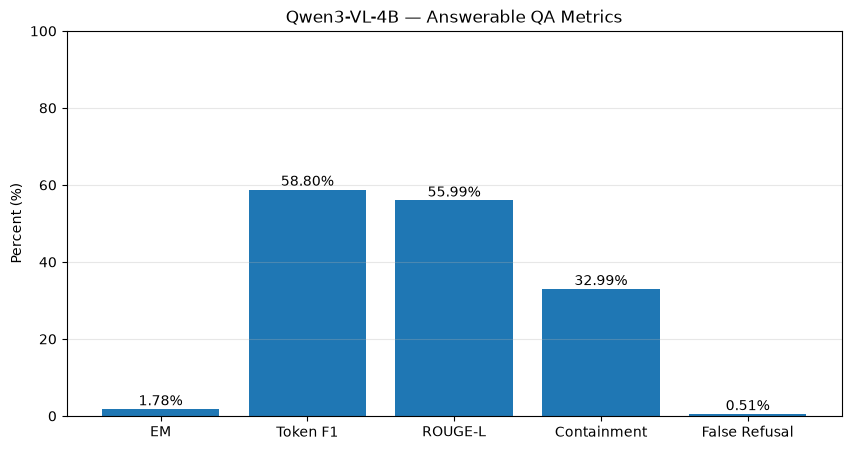

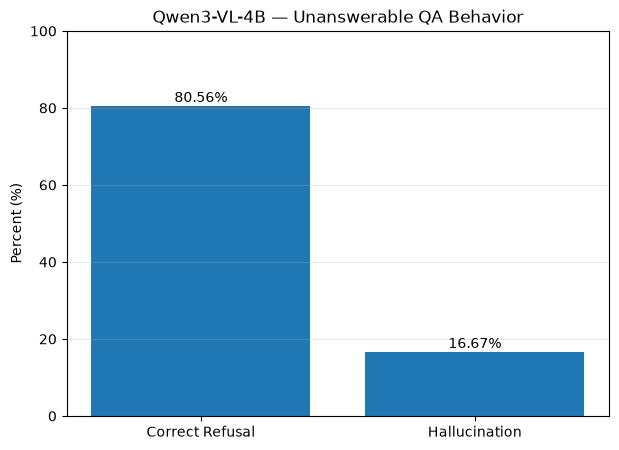

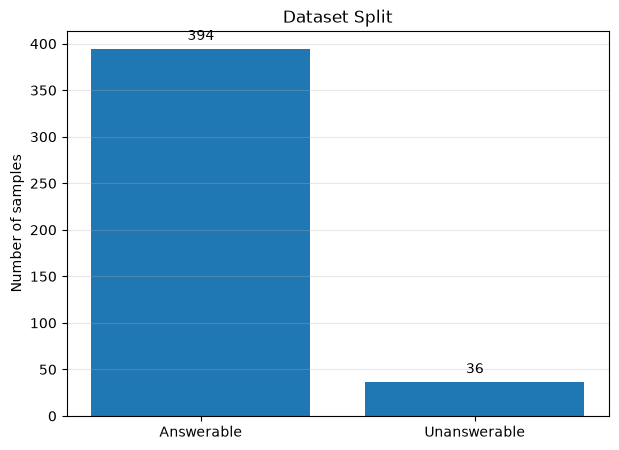

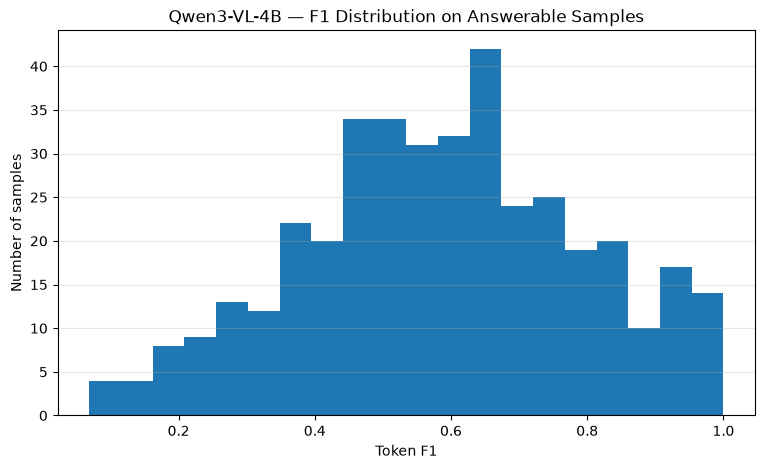


✅ Qwen fixed benchmark results saved to:
/home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/gpt41_mini_domain_test


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 │ 💾 SAVE RESULTS + CHARTS — QWEN FIXED BENCHMARK
# ─────────────────────────────────────────────────────────────────────────────
import json
import matplotlib.pyplot as plt

results_jsonl = OUTPUT_DIR / "qwen_predictions_fixed_metrics.jsonl"
results_csv = OUTPUT_DIR / "qwen_predictions_fixed_metrics.csv"
summary_csv = OUTPUT_DIR / "qwen_summary_fixed_metrics.csv"
summary_json = OUTPUT_DIR / "qwen_summary_fixed_metrics.json"

with open(results_jsonl, "w", encoding="utf-8") as f:
    for row in rows:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

df.to_csv(results_csv, index=False, encoding="utf-8-sig")
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")

with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved fixed metrics:")
print(results_jsonl)
print(results_csv)
print(summary_csv)
print(summary_json)

# Chart 1: Answerable QA metrics
metric_names = ["EM", "Token F1", "ROUGE-L", "Containment", "False Refusal"]
metric_values = [
    summary["answerable_em"],
    summary["answerable_f1"],
    summary["answerable_rouge_l"],
    summary["answerable_containment"],
    summary["false_refusal_rate_answerable"]
]

plt.figure(figsize=(10, 5))
plt.bar(metric_names, metric_values)
plt.ylabel("Percent (%)")
plt.title("Qwen3-VL-4B — Answerable QA Metrics")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(metric_values):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")

chart_path = OUTPUT_DIR / "qwen_answerable_metrics.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Chart 2: Unanswerable behavior
metric_names = ["Correct Refusal", "Hallucination"]
metric_values = [
    summary["correct_refusal_rate_unanswerable"],
    summary["hallucination_rate_unanswerable"]
]

plt.figure(figsize=(7, 5))
plt.bar(metric_names, metric_values)
plt.ylabel("Percent (%)")
plt.title("Qwen3-VL-4B — Unanswerable QA Behavior")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(metric_values):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")

chart_path = OUTPUT_DIR / "qwen_unanswerable_behavior.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Chart 3: Dataset split
split_names = ["Answerable", "Unanswerable"]
split_values = [
    summary["answerable_samples"],
    summary["unanswerable_samples"]
]

plt.figure(figsize=(7, 5))
plt.bar(split_names, split_values)
plt.ylabel("Number of samples")
plt.title("Dataset Split")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(split_values):
    plt.text(i, v + 10, str(v), ha="center")

chart_path = OUTPUT_DIR / "dataset_split.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Chart 4: F1 distribution on answerable only
plt.figure(figsize=(9, 5))
plt.hist(answerable_df["f1"], bins=20)
plt.xlabel("Token F1")
plt.ylabel("Number of samples")
plt.title("Qwen3-VL-4B — F1 Distribution on Answerable Samples")
plt.grid(axis="y", alpha=0.3)

chart_path = OUTPUT_DIR / "qwen_answerable_f1_distribution.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

print("\n✅ Qwen fixed benchmark results saved to:")
print(OUTPUT_DIR.resolve())

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 │ 📝 SAVE QWEN FIXED BENCHMARK REPORT
# ─────────────────────────────────────────────────────────────────────────────

report_path = OUTPUT_DIR / "qwen_benchmark_report_fixed_metrics.md"

report = f"""# Benchmark Report — Qwen3-VL-4B-Instruct Baseline

## Model

`{MODEL_NAME}`

## Judge Model (local)

`{JUDGE_MODEL_NAME}`

## Dataset

`{DATASET_PATH}`

Number of samples: **{len(df)}**

- Answerable samples: **{summary["answerable_samples"]}**
- Unanswerable samples: **{summary["unanswerable_samples"]}**

## Main Results

### Answerable QA

| Metric | Value |
|---|---:|
| Answerable EM | {summary["answerable_em"]:.2f}% |
| Answerable Token F1 | {summary["answerable_f1"]:.2f}% |
| Answerable ROUGE-L | {summary["answerable_rouge_l"]:.2f}% |
| Containment Accuracy | {summary["answerable_containment"]:.2f}% |
| False Refusal Rate | {summary["false_refusal_rate_answerable"]:.2f}% |

### Unanswerable QA

| Metric | Value |
|---|---:|
| Correct Refusal Rate | {summary["correct_refusal_rate_unanswerable"]:.2f}% |
| Hallucination Rate on Unanswerable | {summary["hallucination_rate_unanswerable"]:.2f}% |

### Overall

| Metric | Value |
|---|---:|
| Overall EM | {summary["overall_em"]:.2f}% |
| Overall Token F1 | {summary["overall_f1"]:.2f}% |
| Overall ROUGE-L | {summary["overall_rouge_l"]:.2f}% |
| Average Latency | {summary["avg_latency_sec"]:.4f} sec/sample |
| Throughput | {summary["throughput_samples_per_sec"]:.2f} samples/sec |

## Interpretation

This benchmark follows a SQuAD2.0 / ViQuAD2.0-style evaluation because the dataset contains both answerable and unanswerable questions.

For answerable samples, EM, Token F1, ROUGE-L, and Containment Accuracy measure answer quality. Containment Accuracy is useful when the model generates a complete sentence while the gold answer is a short span.

For unanswerable samples, Correct Refusal Rate measures whether the model correctly refuses to answer when the context does not contain the answer. Hallucination Rate measures cases where the model produces an answer despite the gold label being unanswerable.

LLM-as-judge scoring (refusal / hallucination / faithfulness) is now performed locally with `{JUDGE_MODEL_NAME}` via vLLM instead of calling an external API.

## Output Files

- `qwen_predictions_fixed_metrics.jsonl`
- `qwen_predictions_fixed_metrics.csv`
- `qwen_summary_fixed_metrics.csv`
- `qwen_summary_fixed_metrics.json`
- `qwen_answerable_metrics.png`
- `qwen_unanswerable_behavior.png`
- `dataset_split.png`
- `qwen_answerable_f1_distribution.png`
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("✅ Qwen fixed report saved:")
print(report_path.resolve())

✅ Qwen fixed report saved:
/home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/gpt41_mini_domain_test/qwen_benchmark_report_fixed_metrics.md
